In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned dataset from Task 1
filtered_df = pd.read_csv("../data/processed/filtered_complaints.csv")
print("Dataset shape:", filtered_df.shape)


Dataset shape: (553859, 18)


Product
Checking or savings account                  291178
Credit card                                  226686
Payday loan, title loan, or personal loan     30641
Money transfers                                5354
Name: count, dtype: int64


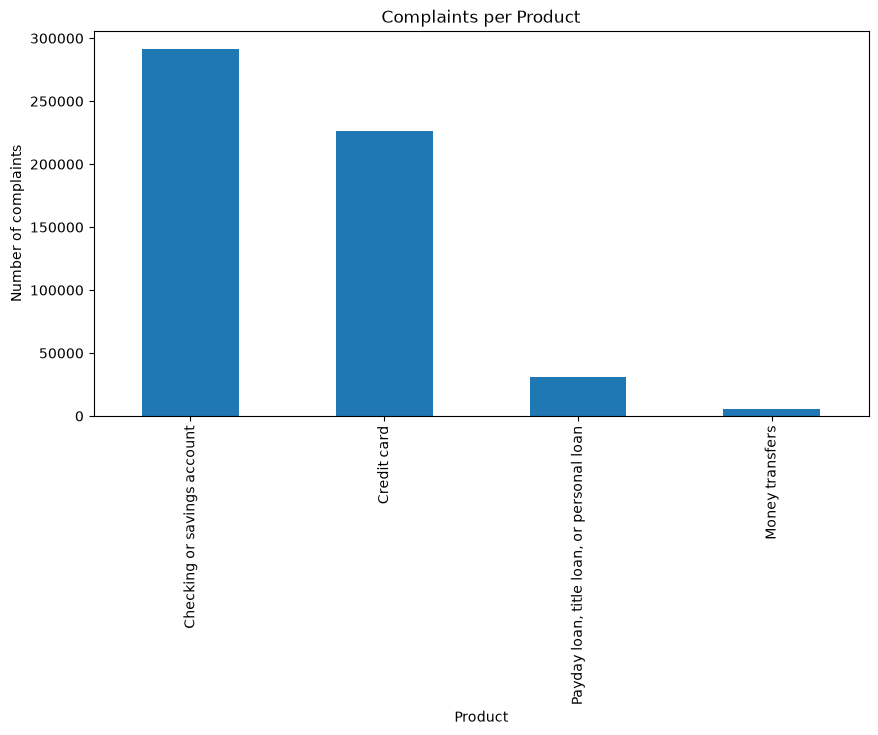

In [2]:
# count complane per prodact
product_counts = filtered_df['Product'].value_counts()
print(product_counts)

# Plot bar chart
product_counts.plot(kind='bar', figsize=(10,5), title="Complaints per Product")
plt.ylabel("Number of complaints")
plt.show()


In [4]:
filtered_df['narrative_length'] = filtered_df['Consumer complaint narrative'].fillna("").str.split().str.len()


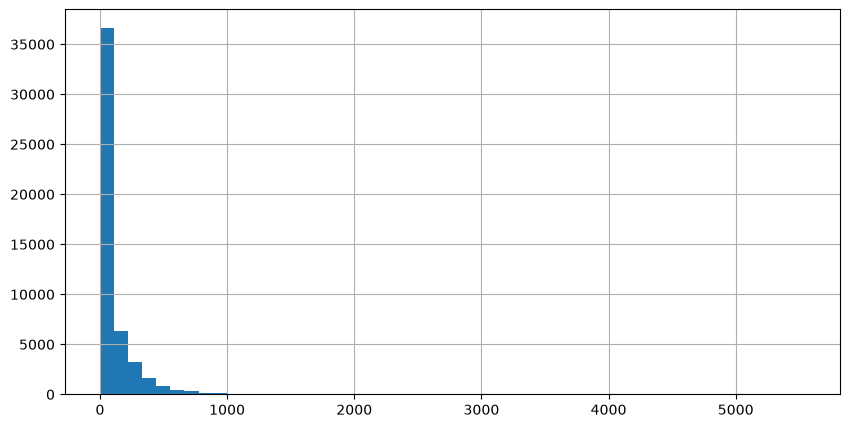

narrative_length
0      314138
77       4338
75       1714
27       1662
76       1304
31       1263
43       1202
23       1162
53       1135
39       1131
78       1111
46       1069
51       1066
85       1055
100      1049
48       1037
40       1029
74       1022
49       1021
41       1017
Name: count, dtype: int64


In [5]:
# megering narative length
# Create narrative_length column
sample_df = filtered_df.sample(50000, random_state=42)
sample_df['narrative_length'].hist(bins=50, figsize=(10,5))
plt.show()
print(filtered_df['narrative_length'].value_counts().head(20))


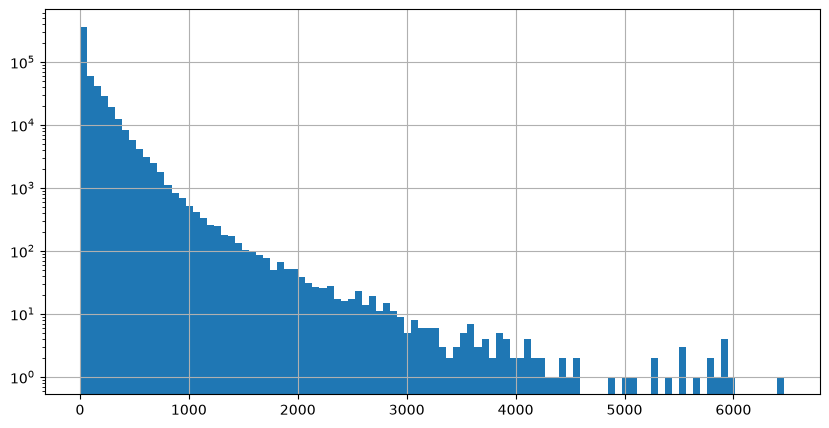

In [6]:
filtered_df['narrative_length'].hist(bins=100, figsize=(10,5), log=True)
plt.show()


In [7]:
print(filtered_df['narrative_length'].describe())


count    553859.000000
mean         91.940183
std         186.685106
min           0.000000
25%           0.000000
50%           0.000000
75%         122.000000
max        6469.000000
Name: narrative_length, dtype: float64


In [8]:
missing_narratives = filtered_df['Consumer complaint narrative'].isna().sum()
print("Missing complaint narratives:", missing_narratives)


Missing complaint narratives: 314138


In [10]:
# Drop rows where narrative is missing or empty
filtered_df = filtered_df[filtered_df['Consumer complaint narrative'].notna()]
filtered_df = filtered_df[filtered_df['Consumer complaint narrative'].str.strip() != ""]

print("After dropping empty narratives:", filtered_df.shape)


After dropping empty narratives: (239721, 19)


In [11]:
print(filtered_df['narrative_length'].describe())


count    239721.000000
mean        212.421515
std         234.369094
min           1.000000
25%          77.000000
50%         149.000000
75%         268.000000
max        6469.000000
Name: narrative_length, dtype: float64


In [12]:
print(filtered_df['Product'].value_counts())


Product
Checking or savings account                  140319
Credit card                                   80667
Payday loan, title loan, or personal loan     17238
Money transfers                                1497
Name: count, dtype: int64


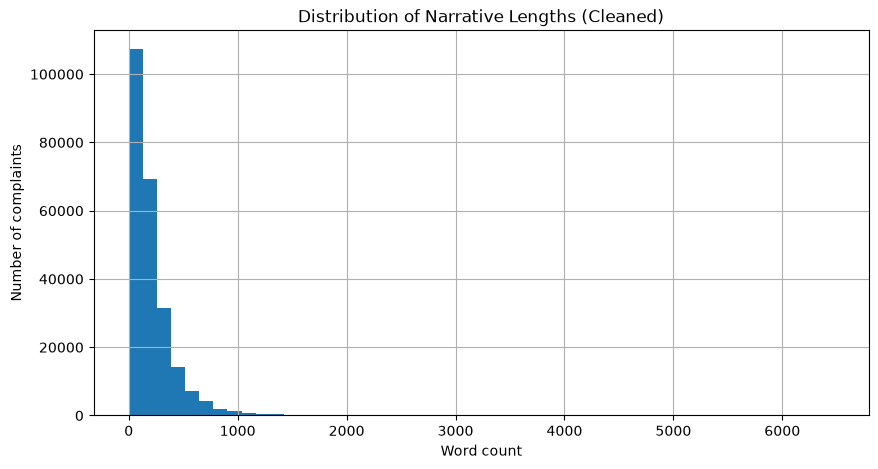

In [13]:
filtered_df['narrative_length'].hist(bins=50, figsize=(10,5))
plt.title("Distribution of Narrative Lengths (Cleaned)")
plt.xlabel("Word count")
plt.ylabel("Number of complaints")
plt.show()


In [14]:
# Save the cleaned dataset to the processed folder
filtered_df.to_csv("../data/processed/filtered_complaints.csv", index=False)

print("Processed dataset saved to data/processed/filtered_complaints.csv")


Processed dataset saved to data/processed/filtered_complaints.csv
